# 04 Simple GAN Experiment: Learning to Generate Real 911-Call Locations

**Unit:** Unit 5: Introduction to Generative AI and Course Summary

**Why this notebook?** In example 02 we saw that a *generative* model learns the data
distribution P(X) itself, while a *discriminative* model only learns the boundary
P(Y|X). That raises an obvious practical question: how do you actually *train* a
network to generate realistic new samples when there is no "correct answer" to
compare each output against? A Generative Adversarial Network (GAN) solves this with
a trick: it uses a **discriminative model as the teacher** for a generative one. Here
we build the smallest GAN that shows the idea working — a generator that learns to
produce 2D points shaped like the **real map of emergency calls** in two Pennsylvania
townships (Norristown and Pottstown) — so you can watch the adversarial game converge in a couple of seconds on a CPU.

The target distribution is **real data**: latitude/longitude of 911 calls logged in
Montgomery County, PA. The two townships sit far apart on the map, so the real
distribution has two genuinely separated clusters — and a generator that only learns one
of them has *mode collapsed*, exactly the failure we want to be able to measure.

## 📚 Learning Objectives

By completing this notebook, you will:
- See why a plain supervised loss (MSE) fails at generation — it collapses to the average
- Build a generator and a discriminator as tiny Keras `Dense` networks
- Train them with a custom adversarial training loop (~2000 steps)
- Read GAN loss curves and understand why neither loss goes to zero
- Check generation quality with simple honest metrics (nearest-neighbour distances, mode coverage)

## 🔗 Where this fits

**Builds on:** Unit 5, lesson 02 "Generative vs Discriminative Models" — the two paradigms are now put in one training loop, competing.

**Used later in:** Course 10 (AIAT 124) — Unit 1, which rebuilds this GAN in PyTorch and adds conditioning, StyleGAN and evaluation metrics.

---


## 🎯 A face that belonged to nobody

In February 2019 a developer put NVIDIA's **StyleGAN** behind a single web page —
*thispersondoesnotexist.com* — which produced a new, photorealistic human face on
every refresh. None of them were people. The technique was the one you are about to
build: a generator trained not against labelled targets but against a
**discriminator** that is simultaneously learning to spot fakes.

Four months later the Associated Press reported what that capability was already
being used for. A LinkedIn profile for "Katie Jones" — a thirty-something with a
job at a Washington think tank — had connected with a deputy assistant secretary
of state, a senate aide, and an economist under consideration for a Federal Reserve
seat. Katie Jones does not exist. Experts interviewed by the AP concluded her
photograph had been generated by a GAN, and that the profile's behaviour matched
known espionage patterns on the platform. It was first flagged by a Russia
specialist at Chatham House who found the invitation suspicious.

That is the two-sentence case for this notebook. **The adversarial trick works** —
well enough that a generated face passes as a colleague. And a generated sample
has no origin you can trace, which is a technical fact with consequences that
turned up in a national-security story within months of the capability existing.

### What goes wrong with the obvious approach

You will see it in the baseline below, before any adversary exists. Train a
generator with MSE against randomly paired real points and it converges to a tiny
blob at the mean: per-axis standard deviation **0.04** against the real data's
**1.0**, sitting in empty countryside between the two towns. That blob is the
*best* a per-sample MSE can do, and it is useless as generation. **A per-sample
loss cannot reward variety**, because
variety is a property of the distribution, not of any one sample. The
discriminator exists to supply a signal that can see the whole distribution.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- A **real** 2D dataset: 2,000 sampled 911-call coordinates (lat/lng) from two Montgomery County
  townships, loaded with `load("montgomery_911_calls", prefer="sample")` — the 25,000-row sample
  that ships inside this repository, so there is nothing to download and every machine (yours,
  the instructor's, Google Colab) reads exactly the same calls
- TensorFlow/Keras for the generator, discriminator, and custom training loop

**Outputs:** What you'll see when you run the cells

- A scatter plot of the real call-location distribution
- A baseline experiment: an MSE-trained generator that collapses to the data mean
- Training progress lines every 250 steps (losses + distance metrics)
- A final figure: a 3×3 grid of snapshots showing generated points converging onto
  the real distribution, plus the generator/discriminator loss curves
- A printed side-by-side comparison table: MSE baseline vs adversarial training

---

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("montgomery_911_calls"), ...
# -------------------------------------------------------------------------------------

TensorFlow: 2.21.0 | Keras: 3.15.1
montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
Dispatch log as loaded: 25,000 real emergency calls
Out-of-county coordinates caught by the bounding-box guard: 0

Real dataset: 2000 calls, 2 features (lng, lat) — sampled from 2,524 calls with random_state=42
  NORRISTOWN    : 1210 calls (60.5% of the sample)
  POTTSTOWN     :  790 calls (39.5% of the sample)
Per-axis mean: [ 0. -0.] | per-axis std: [1. 1.]


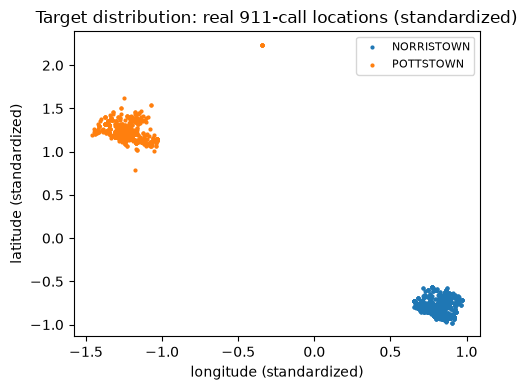

In [2]:
# GAN experiment setup: the generator must learn to produce points shaped like the REAL
# map of 911 calls in two townships. 2D data keeps everything visible — you can SEE the
# distribution being learned, and you can see if a whole township goes missing.
"""
Unit 5 - Example 4: Simple GAN Experiment (real 911-call locations)

Setup: imports, seeds, and the real target distribution the generator must learn.
"""

import time
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

t_start = time.time()
print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)

SEED = 42
keras.utils.set_random_seed(SEED)  # seeds Python, NumPy and TensorFlow

# ---- REAL DATA ----
# WHAT: Montgomery County (PA) 911 dispatch log, three columns, through the shared loader.
#       No file path, so this works from any folder and on Google Colab.
# WHY prefer="sample": the full 123 MB log is a Kaggle download almost nobody in the class
#       will have. Pinning the bundled 25,000-row sample means your machine, the
#       instructor's machine and Colab all read the same calls and print the same numbers.
calls_all = load("montgomery_911_calls", prefer="sample", usecols=["lat", "lng", "twp"])
calls = calls_all          # `calls` gets filtered below; `calls_all` stays the whole log
print(f"Dispatch log as loaded: {len(calls):,} real emergency calls")

# Two townships that sit far apart on the map. Their calls form two clearly separated
# real clusters — our stand-in for "two modes" that the generator must both cover.
TOWNSHIPS = ["NORRISTOWN", "POTTSTOWN"]
calls = calls[calls["twp"].isin(TOWNSHIPS)].dropna(subset=["lat", "lng"])

# Real data has real errors: a few rows in the full log carry coordinates from other states
# (typos in the dispatch system). Keep the bounding-box guard whichever copy you are reading,
# and print what it actually caught rather than what we expect it to catch.
in_county = calls["lat"].between(39.9, 40.5) & calls["lng"].between(-75.8, -74.9)
print(f"Out-of-county coordinates caught by the bounding-box guard: {(~in_county).sum()}")
calls = calls[in_county]

# Classroom-size the data honestly: a 2,000-call random sample, random_state=42.
N_REAL = 2000
sample = calls.sample(n=N_REAL, random_state=42)
X_raw = sample[["lng", "lat"]].to_numpy()          # x = longitude, y = latitude
y_town = (sample["twp"] == TOWNSHIPS[0]).to_numpy().astype(int)   # 1 = Norristown

print(f"\nReal dataset: {X_raw.shape[0]} calls, {X_raw.shape[1]} features "
      f"(lng, lat) — sampled from {len(calls):,} calls with random_state=42")
for i, name in enumerate(TOWNSHIPS):
    n = int((y_town == (1 - i)).sum())
    print(f"  {name:<14}: {n:4d} calls ({n / N_REAL:.1%} of the sample)")

# Standardize to zero mean / unit std so both networks see well-scaled inputs.
X_real = ((X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)).astype("float32")
print("Per-axis mean:", X_real.mean(axis=0).round(3), "| per-axis std:", X_real.std(axis=0).round(3))

REAL_BALANCE = float(y_town.mean())   # the real proportion the generator should match

plt.figure(figsize=(5, 4))
for i, name in enumerate(TOWNSHIPS):
    m = y_town == (1 - i)
    plt.scatter(X_real[m, 0], X_real[m, 1], s=4, label=name)
plt.title("Target distribution: real 911-call locations (standardized)")
plt.xlabel("longitude (standardized)"); plt.ylabel("latitude (standardized)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Honest measurement first

"The samples look right" is not a measurement. Before training anything we define
three cheap, printable metrics and use them for **every** experiment below:

- **gen→real distance** — average distance from each generated point to its nearest
  real point. Small = generated points sit *on* the data manifold (quality).
- **real→gen distance** — average distance from each real point to its nearest
  generated point. Small = the generator *covers* the whole distribution
  (this is the one that catches **mode collapse**: if the generator only produces
  calls from one township, real→gen stays large even when gen→real is small).
- **mode balance** — fraction of generated points whose nearest real neighbour is a
  **Norristown** call. Note the target here is *not* 0.50: the real sample is
  genuinely imbalanced, so a generator that covers the distribution faithfully should
  land near the real proportion printed above. Real data does not come in equal halves,
  and neither should a generator's output.

In [3]:
# Measurement tools and model builders. The three metrics (spread, two-way nearest-
# neighbour distance, mode balance) will tell us objectively whether generated points
# cover BOTH townships, or quietly abandon one of them.
def nn_dist(A, B):
    """Average over rows of A of the distance to the nearest row of B."""
    d = np.sqrt(((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=-1))
    return float(d.min(axis=1).mean())


def mode_balance(points):
    """Fraction of points whose nearest real neighbour is a Norristown call."""
    d = np.sqrt(((points[:, None, :] - X_real[None, :, :]) ** 2).sum(axis=-1))
    return float(y_town[d.argmin(axis=1)].mean())


def report(name, points):
    print(f"{name:<22} per-axis std {points.std(axis=0).round(2)}  "
          f"gen->real {nn_dist(points, X_real):.3f}  "
          f"real->gen {nn_dist(X_real, points):.3f}  "
          f"mode balance {mode_balance(points):.2f}")


LATENT = 8    # generator input: 8D Gaussian noise
HIDDEN = 64   # width of the two small hidden Dense layers in each network
BATCH = 128


def make_generator():
    """Noise z (8D) -> 2D point. Two small hidden Dense layers + linear output."""
    return keras.Sequential([
        layers.Input(shape=(LATENT,)),
        layers.Dense(HIDDEN, activation="relu"),
        layers.Dense(HIDDEN, activation="relu"),
        layers.Dense(2),
    ], name="generator")


# Sanity check the metrics on the real data itself: distances ~0, and a balance equal
# to the real township proportion (NOT 0.50 — this dataset is genuinely imbalanced).
report("real data vs itself", X_real)
print(f"Real Norristown share (the number a faithful generator should match): {REAL_BALANCE:.2f}")

real data vs itself    per-axis std [1. 1.]  gen->real 0.000  real->gen 0.000  mode balance 0.60
Real Norristown share (the number a faithful generator should match): 0.60


## Baseline: the obvious idea, and why it fails

The obvious way to train a generator is supervised learning: sample noise `z`, pick a
random real point as the "target", and minimize the MSE between them. Every tool we
need is familiar from earlier units.

But think about what that loss asks for. Each noise vector gets paired with a
*different random* real point every step, so the best a deterministic network can do
is output something close to **all** targets at once — the **average** of the data.
The loss cannot reward variety; it rewards playing it safe. Let's confirm that
prediction by running it.

MSE baseline: 1000 steps in 0.6s, final MSE loss 1.066
MSE generator          per-axis std [0.04 0.04]  gen->real 0.944  real->gen 1.219  mode balance 1.00
real data vs itself    per-axis std [1. 1.]  gen->real 0.000  real->gen 0.000  mode balance 0.60


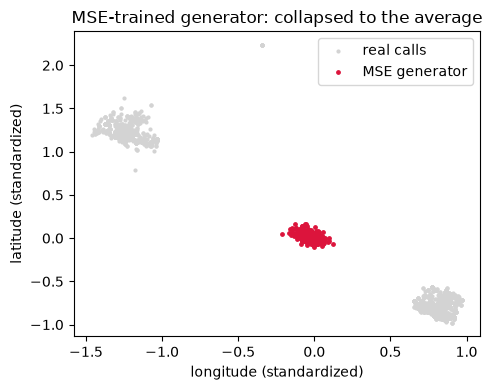

In [4]:
# Baseline WITHOUT an adversary: train the generator by MSE against randomly paired
# real points. It collapses to the average — the failure that motivates the discriminator.
g_mse = make_generator()
mse_opt = keras.optimizers.Adam(1e-3)
rng = np.random.default_rng(SEED)


@tf.function
def mse_step(z, x_target):
    with tf.GradientTape() as tape:
        fake = g_mse(z, training=True)
        loss = tf.reduce_mean(tf.square(fake - x_target))
    grads = tape.gradient(loss, g_mse.trainable_variables)
    mse_opt.apply_gradients(zip(grads, g_mse.trainable_variables))
    return loss

t0 = time.time()
for step in range(1000):
    z = tf.random.normal((BATCH, LATENT))
    x_target = X_real[rng.integers(0, N_REAL, BATCH)]  # random pairing
    loss = mse_step(z, x_target)
print(f"MSE baseline: 1000 steps in {time.time() - t0:.1f}s, final MSE loss {float(loss):.3f}")

z_eval = tf.random.normal((500, LATENT), seed=7)
mse_points = g_mse(z_eval, training=False).numpy()
report("MSE generator", mse_points)
report("real data vs itself", X_real)

plt.figure(figsize=(5, 4))
plt.scatter(X_real[:, 0], X_real[:, 1], s=4, c="lightgray", label="real calls")
plt.scatter(mse_points[:, 0], mse_points[:, 1], s=6, c="crimson", label="MSE generator")
plt.title("MSE-trained generator: collapsed to the average")
plt.xlabel("longitude (standardized)"); plt.ylabel("latitude (standardized)")
plt.legend(); plt.tight_layout(); plt.show()

**Baseline conclusion (matches the printout above):** the MSE generator's per-axis
std is **0.04** vs 1.0 for the real data, and the real→gen distance is large (**1.219**) —
every real call location is far from the nearest generated one. Its mode balance reads
**1.00**, but do not read that as "it produces Norristown calls": the blob sits in empty
countryside, and 1.00 only says the nearest *real* call to every generated point happens to
be a Norristown one. The samples are a tiny blob near the data mean: technically the lowest
loss this objective can reach, useless as generation.

## Change one thing: replace the fixed target with a learned judge

Keep the *exact same generator architecture*. The one thing we change is the training
signal: instead of "match this random point", the generator is scored by a second
network — a **discriminator** — that is itself being trained to tell real points from
generated ones. This is the adversarial game:

- The **discriminator** (a plain binary classifier, exactly the discriminative
  P(real | x) model from example 02) is trained to output "real" on data points and
  "fake" on generator outputs.
- The **generator** never sees real data directly. Its loss is simply "make the
  discriminator say *real*", and its gradients flow *through* the discriminator.

Counterfeiter vs. detective: as the detective gets sharper, the only way for the
counterfeiter to keep winning is to produce points that lie on the true distribution
— *everywhere* on it, because any under-covered region is an easy tell. Abandoning
Pottstown entirely would be the easiest tell of all. That pressure toward variety is
exactly what MSE lacked.

Two standard stability tricks, honestly declared: `Adam(beta_1=0.5)` for both
networks, and label smoothing (real labels = 0.9) for the discriminator.

In [5]:
# The real GAN: discriminator learns to tell real from fake while the generator learns
# to fool it — a two-player game where each step trains both networks in turn.
# Fresh seeds so this experiment does not depend on how many random draws
# the baseline consumed above.
keras.utils.set_random_seed(SEED)
rng_gan = np.random.default_rng(SEED)

generator = make_generator()
discriminator = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(HIDDEN, activation=layers.LeakyReLU(0.2)),
    layers.Dense(HIDDEN, activation=layers.LeakyReLU(0.2)),
    layers.Dense(1),  # logit: >0 means "looks real"
], name="discriminator")
print(f"generator params: {generator.count_params():,} | "
      f"discriminator params: {discriminator.count_params():,}")

g_opt = keras.optimizers.Adam(1e-3, beta_1=0.5)
d_opt = keras.optimizers.Adam(1e-3, beta_1=0.5)
bce = keras.losses.BinaryCrossentropy(from_logits=True)


@tf.function
def gan_step(x_real_batch):
    # --- 1) discriminator step: real -> 0.9 (label smoothing), fake -> 0
    z = tf.random.normal((BATCH, LATENT))
    with tf.GradientTape() as tape:
        fake = generator(z, training=True)
        real_logits = discriminator(x_real_batch, training=True)
        fake_logits = discriminator(fake, training=True)
        d_loss = (bce(tf.ones_like(real_logits) * 0.9, real_logits)
                  + bce(tf.zeros_like(fake_logits), fake_logits))
    d_grads = tape.gradient(d_loss, discriminator.trainable_variables)
    d_opt.apply_gradients(zip(d_grads, discriminator.trainable_variables))

    # --- 2) generator step: make the discriminator output "real" on fakes
    z = tf.random.normal((BATCH, LATENT))
    with tf.GradientTape() as tape:
        fake = generator(z, training=True)
        fake_logits = discriminator(fake, training=True)
        g_loss = bce(tf.ones_like(fake_logits), fake_logits)
    g_grads = tape.gradient(g_loss, generator.trainable_variables)
    g_opt.apply_gradients(zip(g_grads, generator.trainable_variables))
    return d_loss, g_loss


# The training loop: snapshot the generator's output every 250 steps so we can watch
# the two real township clusters form.
STEPS = 2000
SNAP_EVERY = 250
z_vis = tf.random.normal((500, LATENT), seed=7)  # fixed noise for all snapshots

d_hist, g_hist, snapshots = [], [], {}
t0 = time.time()
for step in range(STEPS + 1):
    if step % SNAP_EVERY == 0:
        pts = generator(z_vis, training=False).numpy()
        snapshots[step] = pts
        d_str = f"{d_hist[-1]:.3f}" if d_hist else "  -  "
        g_str = f"{g_hist[-1]:.3f}" if g_hist else "  -  "
        print(f"step {step:4d} | d_loss {d_str} g_loss {g_str} | "
              f"gen->real {nn_dist(pts, X_real):.3f}  real->gen {nn_dist(X_real, pts):.3f}  "
              f"balance {mode_balance(pts):.2f}")
    if step < STEPS:
        d_loss, g_loss = gan_step(X_real[rng_gan.integers(0, N_REAL, BATCH)])
        d_hist.append(float(d_loss)); g_hist.append(float(g_loss))

print(f"Adversarial training: {STEPS} steps in {time.time() - t0:.1f}s")

generator params: 4,866 | discriminator params: 4,417
step    0 | d_loss   -   g_loss   -   | gen->real 1.120  real->gen 1.028  balance 0.54


step  250 | d_loss 1.348 g_loss 0.861 | gen->real 0.512  real->gen 0.034  balance 0.67
step  500 | d_loss 1.244 g_loss 0.964 | gen->real 0.165  real->gen 0.030  balance 0.78
step  750 | d_loss 1.156 g_loss 1.142 | gen->real 0.062  real->gen 0.031  balance 0.89


step 1000 | d_loss 1.269 g_loss 0.980 | gen->real 0.048  real->gen 0.019  balance 0.79
step 1250 | d_loss 1.317 g_loss 0.983 | gen->real 0.040  real->gen 0.026  balance 0.73
step 1500 | d_loss 1.366 g_loss 0.898 | gen->real 0.053  real->gen 0.021  balance 0.71


step 1750 | d_loss 1.353 g_loss 0.867 | gen->real 0.029  real->gen 0.029  balance 0.68
step 2000 | d_loss 1.365 g_loss 0.869 | gen->real 0.021  real->gen 0.030  balance 0.67
Adversarial training: 2000 steps in 1.2s


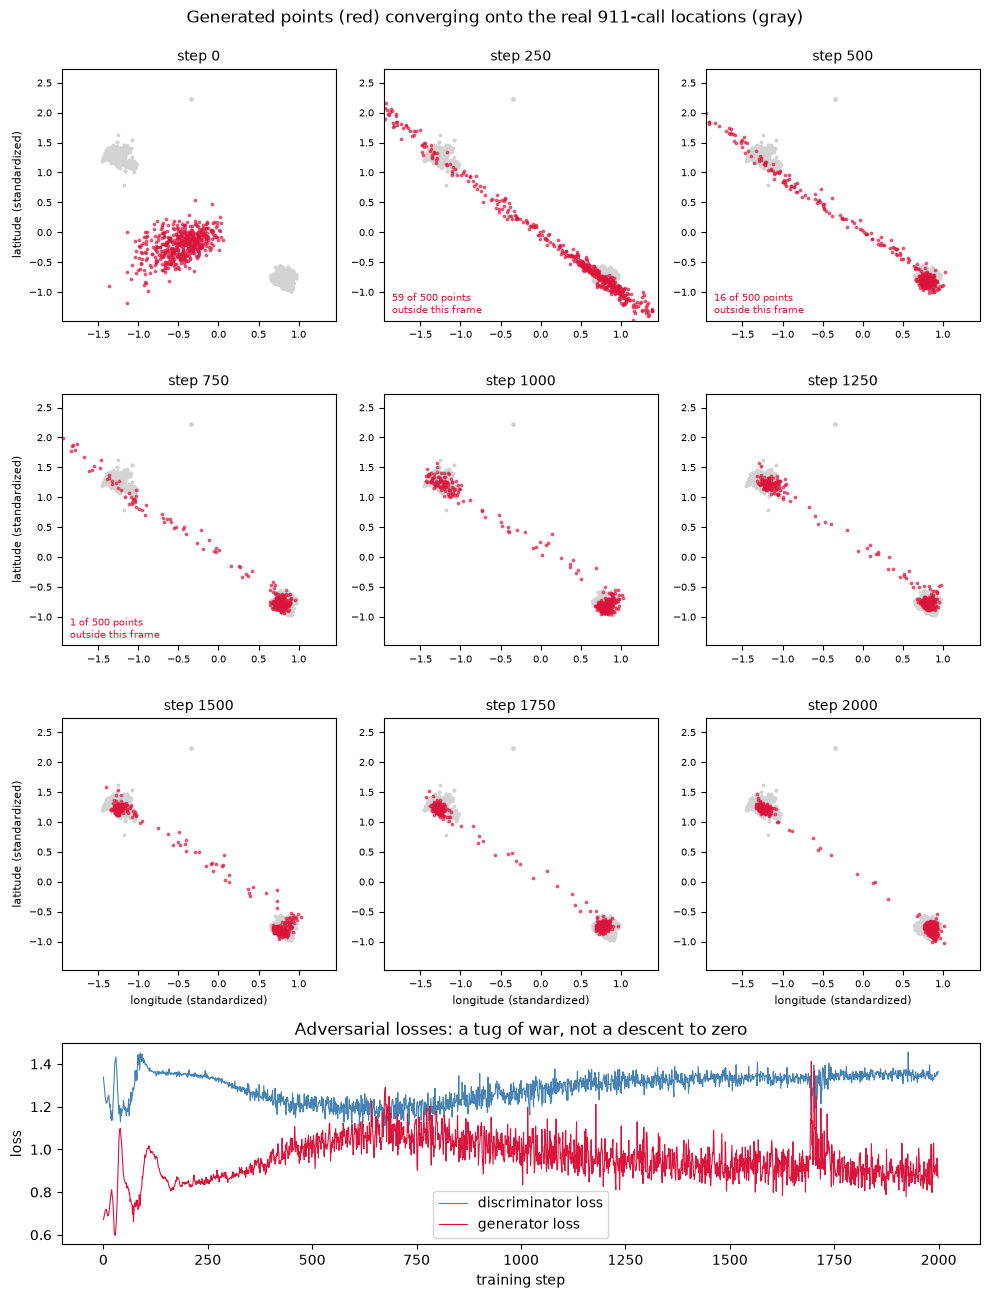

Points thrown outside the shared frame, per snapshot (out of 500):
  step 250: 59  step 500: 16  step 750: 1
Mean d_loss over last 500 steps: 1.338
Mean g_loss over last 500 steps: 0.917


In [6]:
# The payoff picture: nine snapshots of generated points converging onto the real call
# map, plus the loss curves — note they oscillate in balance rather than dropping to zero.
# Final figure: 3x3 grid of snapshots (top) + the two loss curves (bottom).
fig = plt.figure(figsize=(10, 13))
gs = fig.add_gridspec(4, 3, height_ratios=[1, 1, 1, 0.8])

# One shared frame for all nine panels, sized to the REAL call map plus a margin. Sharing it
# is what makes the frames comparable. Sizing it to the real data (rather than to whatever the
# untrained generator flings out) is what keeps the two towns big enough to see — early
# snapshots throw points outside the county, and each panel says how many, so nothing is
# quietly cropped away.
lo = X_real.min(axis=0) - 0.5
hi = X_real.max(axis=0) + 0.5

for i, (step, pts) in enumerate(snapshots.items()):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    ax.scatter(X_real[:, 0], X_real[:, 1], s=3, c="lightgray")
    ax.scatter(pts[:, 0], pts[:, 1], s=3, c="crimson", alpha=0.6)
    ax.set_title(f"step {step}", fontsize=10)
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1])
    ax.tick_params(labelsize=7)
    n_off_frame = int(((pts < lo) | (pts > hi)).any(axis=1).sum())
    if n_off_frame:
        ax.text(0.03, 0.03, f"{n_off_frame} of {len(pts)} points\noutside this frame",
                transform=ax.transAxes, fontsize=7, color="crimson")
    if i // 3 == 2:
        ax.set_xlabel("longitude (standardized)", fontsize=8)
    if i % 3 == 0:
        ax.set_ylabel("latitude (standardized)", fontsize=8)

ax = fig.add_subplot(gs[3, :])
ax.plot(d_hist, label="discriminator loss", color="steelblue", linewidth=0.8)
ax.plot(g_hist, label="generator loss", color="crimson", linewidth=0.8)
ax.set_xlabel("training step"); ax.set_ylabel("loss")
ax.set_title("Adversarial losses: a tug of war, not a descent to zero")
ax.legend()

fig.suptitle("Generated points (red) converging onto the real 911-call locations (gray)",
             y=0.995)
plt.tight_layout()
plt.show()

# The panels annotate their own off-frame counts; print them too so the reading below can
# quote a number instead of asking you to trust a caption.
off_frame = {s: int(((pts < lo) | (pts > hi)).any(axis=1).sum()) for s, pts in snapshots.items()}
print("Points thrown outside the shared frame, per snapshot (out of 500):")
print("  " + "  ".join(f"step {s}: {n}" for s, n in off_frame.items() if n))
print(f"Mean d_loss over last 500 steps: {np.mean(d_hist[-500:]):.3f}")
print(f"Mean g_loss over last 500 steps: {np.mean(g_hist[-500:]):.3f}")

### 📊 Read the storyboard

Nine frames, one shared frame of the real call map (grey), one fixed batch of noise pushed through
the generator at each snapshot (red).

- **Step 0.** An untrained blob (per-axis std 0.25 / 0.22) sitting in the empty ground *between* the
  two towns — not on either of them. Its gen→real distance is **1.120**: every generated point is
  far from every real call. The mode balance of **0.54** is not evidence of good coverage; it only
  says that from out there in the fields, roughly half the blob happens to be nearest a Norristown
  call. Read balance only once gen→real is small.
- **Step 250.** It has overshot badly, smearing into a long streak that covers both towns and
  everything between them; **59 of its 500 points land outside the frame entirely** (printed under
  the figure), out past the edge of the county. That drops to 16 by step 500 and 1 by step 750.
- **Steps 500 → 2000.** The streak is reeled in until the red points sit on both real town
  footprints. Look carefully at the last four frames: a **thin red bridge of points survives across
  the empty middle**, and it is still there at step 2000. The off-map check printed in the next
  cell counts it.
- **Bottom panel.** Neither loss falls towards zero. Both swing hard for the first 500 steps and
  then settle into a tug of war — mean **d_loss 1.338** against **g_loss 0.917** over the last 500
  steps. Each network improving *is* the other one's loss going up, so no loss value here means
  "finished". Sample quality, not loss, is the success measure.

The full numbered reading is in **"What the outputs show"** further down.

In [7]:
# Side-by-side comparison: same generator architecture, different training signal.
gan_points = snapshots[STEPS]

print("Same generator architecture, one change (the training signal):\n")
report("real data (reference)", X_real)
report("MSE baseline", mse_points)
report("GAN, step 0", snapshots[0])
report(f"GAN, step {STEPS}", gan_points)


# THE STORYBOARD SHOWS A THIN RED BRIDGE BETWEEN THE TWO TOWNS. Count it rather than ignore it.
# Yardstick: the distance between the two town centres. A generated point more than a tenth of
# that from EVERY real call is not in either town — it is out in the fields in between.
centre_norristown = X_real[y_town == 1].mean(axis=0)
centre_pottstown = X_real[y_town == 0].mean(axis=0)
town_gap = float(np.linalg.norm(centre_norristown - centre_pottstown))
d_to_real = np.sqrt(((gan_points[:, None, :] - X_real[None, :, :]) ** 2).sum(axis=-1)).min(axis=1)
off_map = 0.10 * town_gap
n_off = int((d_to_real > off_map).sum())

print(f"\nOff-map check: the two town centres are {town_gap:.2f} apart. "
      f"{n_off} of {len(gan_points)} generated points")
print(f"  ({n_off / len(gan_points):.1%}) sit more than {off_map:.2f} from ANY real call, and the "
      f"furthest is {d_to_real.max():.2f} away.")
print("  That is the thin red bridge you can see running between the two towns in the storyboard,")
print("  and it is still there after 2000 steps. A generator maps ONE connected cloud of noise onto")
print("  TWO separated towns, so some of it has to land in the fields in between. The average")
print(f"  gen->real distance of {d_to_real.mean():.3f} hides those points; the picture does not.")

print(f"\nTotal notebook runtime so far: {time.time() - t_start:.1f}s")

Same generator architecture, one change (the training signal):

real data (reference)  per-axis std [1. 1.]  gen->real 0.000  real->gen 0.000  mode balance 0.60
MSE baseline           per-axis std [0.04 0.04]  gen->real 0.944  real->gen 1.219  mode balance 1.00
GAN, step 0            per-axis std [0.25 0.22]  gen->real 1.120  real->gen 1.028  mode balance 0.54
GAN, step 2000         per-axis std [0.97 0.93]  gen->real 0.021  real->gen 0.030  mode balance 0.67

Off-map check: the two town centres are 2.88 apart. 8 of 500 generated points
  (1.6%) sit more than 0.29 from ANY real call, and the furthest is 1.06 away.
  That is the thin red bridge you can see running between the two towns in the storyboard,
  and it is still there after 2000 steps. A generator maps ONE connected cloud of noise onto
  TWO separated towns, so some of it has to land in the fields in between. The average
  gen->real distance of 0.021 hides those points; the picture does not.

Total notebook runtime so far: 2.2

Second experiment: NORRISTOWN 70% / HORSHAM 30% — a more lopsided split than the 60% / 40% pair above


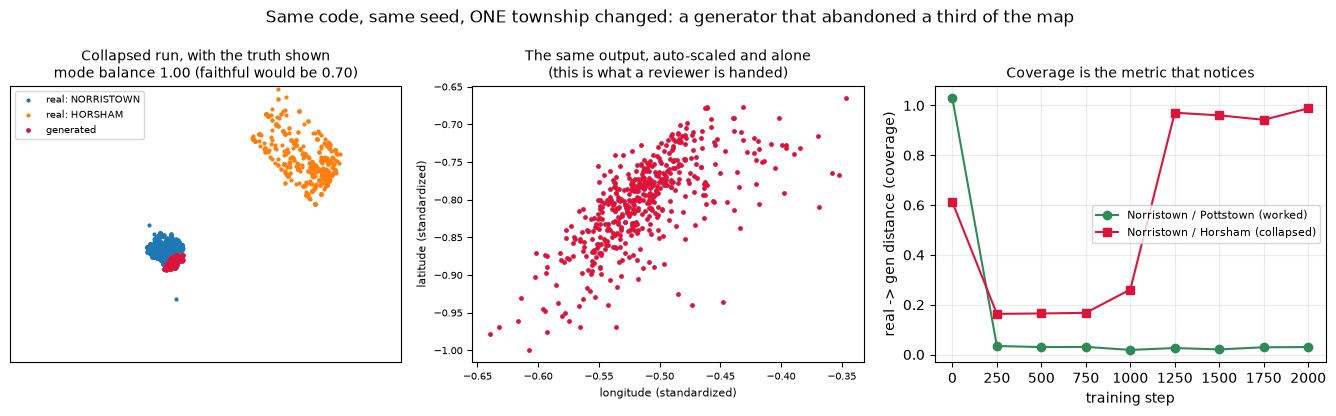


Panel 2 (the collapsed output alone) spans longitude -0.64 to -0.35 and latitude -1.00 to -0.67.
The real data it was trained on spans longitude -0.89 to 2.05 and latitude -1.63 to 2.93. Auto-scaling hides that gap.

Coverage step table (real -> gen distance; lower = the generator covers the real map):
  step    worked   collapsed
     0     1.028       0.611
   250     0.034       0.163
   500     0.030       0.165
   750     0.031       0.167
  1000     0.019       0.261
  1250     0.026       0.971
  1500     0.021       0.960
  1750     0.029       0.942
  2000     0.030       0.988

Same architecture, same seed, same 2000 steps — only the second township differs:
Norristown / Pottstown per-axis std [0.97 0.93]  gen->real 0.021  real->gen 0.030  mode balance 0.67
Norristown / Horsham   per-axis std [0.04 0.06]  gen->real 0.016  real->gen 0.988  mode balance 1.00

The collapsed generator's gen->real distance is 0.016 — its points sit ON
real call locations, which is why panel 2 loo

In [8]:
# SEE THE FAILURE, DO NOT JUST READ ABOUT IT.
# The limitations section below states that this identical code mode-collapses on the
# Norristown / Horsham pair. A warning you cannot see is a warning students forget, so here
# we actually run it: same architecture, same hyper-parameters, same seed, same number of
# steps — and we keep Norristown, so exactly ONE township changes.
# WHY it collapses: honestly, we cannot give you a crisp causal rule. The split is more
# lopsided than the pair above, and a tiny generator can win the adversarial game by serving
# the bigger town and ignoring the other one — nothing in the loss objects to that. But GAN
# collapse is notoriously sensitive to geometry, seed and initialisation, and that is the
# point: you cannot predict it, so you have to MEASURE it. The metrics below are the measurement.
# `calls_all` is the unfiltered log kept from the loader call at the top; `calls` was
# narrowed to the two townships, so we reach for the wider frame here rather than re-reading.
PAIR_BAD = ["NORRISTOWN", "HORSHAM"]
bad = calls_all[calls_all["twp"].isin(PAIR_BAD)].dropna(subset=["lat", "lng"])
bad = bad[bad["lat"].between(39.9, 40.5) & bad["lng"].between(-75.8, -74.9)]
bad = bad.sample(n=N_REAL, random_state=42)
X_bad_raw = bad[["lng", "lat"]].to_numpy()
y_bad = (bad["twp"] == PAIR_BAD[0]).to_numpy().astype(int)      # 1 = Norristown
X_bad = ((X_bad_raw - X_bad_raw.mean(axis=0)) / X_bad_raw.std(axis=0)).astype("float32")
print(f"Second experiment: {PAIR_BAD[0]} {y_bad.mean():.0%} / {PAIR_BAD[1]} {1 - y_bad.mean():.0%} "
      f"— a more lopsided split than the {REAL_BALANCE:.0%} / {1 - REAL_BALANCE:.0%} pair above")

keras.utils.set_random_seed(SEED)          # identical seed to the successful run
rng_bad = np.random.default_rng(SEED)
gen_bad = make_generator()                 # identical architecture
disc_bad = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(HIDDEN, activation=layers.LeakyReLU(0.2)),
    layers.Dense(HIDDEN, activation=layers.LeakyReLU(0.2)),
    layers.Dense(1),
], name="discriminator_bad")
g_opt_b = keras.optimizers.Adam(1e-3, beta_1=0.5)
d_opt_b = keras.optimizers.Adam(1e-3, beta_1=0.5)


@tf.function
def gan_step_bad(x_real_batch):
    """Byte-for-byte the same two-player update as gan_step above."""
    z = tf.random.normal((BATCH, LATENT))
    with tf.GradientTape() as tape:
        fake = gen_bad(z, training=True)
        real_logits = disc_bad(x_real_batch, training=True)
        fake_logits = disc_bad(fake, training=True)
        d_loss = (bce(tf.ones_like(real_logits) * 0.9, real_logits)
                  + bce(tf.zeros_like(fake_logits), fake_logits))
    d_opt_b.apply_gradients(zip(tape.gradient(d_loss, disc_bad.trainable_variables),
                                disc_bad.trainable_variables))
    z = tf.random.normal((BATCH, LATENT))
    with tf.GradientTape() as tape:
        fake = gen_bad(z, training=True)
        g_loss = bce(tf.ones_like(disc_bad(fake, training=True)), disc_bad(fake, training=True))
    g_opt_b.apply_gradients(zip(tape.gradient(g_loss, gen_bad.trainable_variables),
                                gen_bad.trainable_variables))
    return d_loss, g_loss


snap_bad = {}
for step in range(STEPS + 1):
    if step % SNAP_EVERY == 0:
        snap_bad[step] = gen_bad(z_vis, training=False).numpy()
    if step < STEPS:
        gan_step_bad(X_bad[rng_bad.integers(0, N_REAL, BATCH)])
pts_bad = snap_bad[STEPS]

# The two metrics that catch what the eye cannot, computed the same way as everywhere above.
d_bad = np.sqrt(((pts_bad[:, None, :] - X_bad[None, :, :]) ** 2).sum(axis=-1))
bal_bad = float(y_bad[d_bad.argmin(axis=1)].mean())

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

# (1) The truth: both towns are in the data, the generator is sitting on one of them.
for i, name in enumerate(PAIR_BAD):
    m = y_bad == (1 - i)
    axes[0].scatter(X_bad[m, 0], X_bad[m, 1], s=4, label=f"real: {name}")
axes[0].scatter(pts_bad[:, 0], pts_bad[:, 1], s=6, c="crimson", label="generated")
axes[0].set_title(f"Collapsed run, with the truth shown\nmode balance {bal_bad:.2f} "
                  f"(faithful would be {y_bad.mean():.2f})", fontsize=10)
axes[0].legend(fontsize=7); axes[0].set_xlim(-3, 3); axes[0].set_ylim(-3, 3)

# (2) The same generator's output ALONE, plotted the way anyone would plot it if they had
# only the samples: matplotlib's own auto-scaling, no shared frame, no ground truth. Forcing
# panel 1's limits here would betray the point — the tiny blob would advertise its own collapse.
axes[1].scatter(pts_bad[:, 0], pts_bad[:, 1], s=6, c="crimson")
axes[1].set_title("The same output, auto-scaled and alone\n(this is what a reviewer is handed)",
                  fontsize=10)
axes[1].set_xlabel("longitude (standardized)", fontsize=8)
axes[1].set_ylabel("latitude (standardized)", fontsize=8)
axes[1].tick_params(labelsize=7)

# (3) The metric that does see it: coverage of the real data, step by step, for both runs.
steps_axis = sorted(snapshots)
cov_worked = [nn_dist(X_real, snapshots[s]) for s in steps_axis]
cov_collapsed = [nn_dist(X_bad, snap_bad[s]) for s in steps_axis]
axes[2].plot(steps_axis, cov_worked, "o-", color="seagreen",
             label="Norristown / Pottstown (worked)")
axes[2].plot(steps_axis, cov_collapsed, "s-", color="crimson",
             label="Norristown / Horsham (collapsed)")
axes[2].set_xlabel("training step"); axes[2].set_ylabel("real -> gen distance (coverage)")
axes[2].set_title("Coverage is the metric that notices", fontsize=10)
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.25)

axes[0].set_xticks([]); axes[0].set_yticks([])
fig.suptitle("Same code, same seed, ONE township changed: a generator that abandoned a third of the map",
             fontsize=12)
plt.tight_layout()
plt.show()

# The step table behind panel 3: WHEN did the collapse happen? The loss never said.
# Panel 2 has no ground truth and auto-scales, so its tick labels are the only clue that
# anything is wrong. Print the extent rather than asking students to squint at the axes.
print(f"\nPanel 2 (the collapsed output alone) spans longitude "
      f"{pts_bad[:, 0].min():.2f} to {pts_bad[:, 0].max():.2f} and latitude "
      f"{pts_bad[:, 1].min():.2f} to {pts_bad[:, 1].max():.2f}.")
print(f"The real data it was trained on spans longitude "
      f"{X_bad[:, 0].min():.2f} to {X_bad[:, 0].max():.2f} and latitude "
      f"{X_bad[:, 1].min():.2f} to {X_bad[:, 1].max():.2f}. Auto-scaling hides that gap.")

print("\nCoverage step table (real -> gen distance; lower = the generator covers the real map):")
print(f"{'step':>6} {'worked':>9} {'collapsed':>11}")
for st, a, b in zip(steps_axis, cov_worked, cov_collapsed):
    print(f"{st:>6} {a:9.3f} {b:11.3f}")

print("\nSame architecture, same seed, same 2000 steps — only the second township differs:")
report("Norristown / Pottstown", gan_points)
print(f"{'Norristown / Horsham':<22} per-axis std {pts_bad.std(axis=0).round(2)}  "
      f"gen->real {nn_dist(pts_bad, X_bad):.3f}  real->gen {nn_dist(X_bad, pts_bad):.3f}  "
      f"mode balance {bal_bad:.2f}")
print(f"\nThe collapsed generator's gen->real distance is {nn_dist(pts_bad, X_bad):.3f} — its points sit ON")
print("real call locations, which is why panel 2 looks perfectly respectable. Its real->gen distance")
print(f"is {nn_dist(X_bad, pts_bad):.3f}: most of the real map has no generated point anywhere near it.")
print(f"Mode balance {bal_bad:.2f} against a faithful {y_bad.mean():.2f} names the missing third exactly.")

### 📊 Read the three panels

**Panel 1 — the collapsed run, with the answer key showing.** Blue is Norristown, orange is Horsham,
red is what the generator produces. Every red point sits on the blue town. Horsham — **30%** of the
real calls — has no generated point anywhere near it. That is what mode balance **1.00** against a
faithful **0.70** means, drawn.

**Panel 2 — the same 500 red points, plotted the way anyone would plot them if the samples were
all they had.** No ground truth, no shared frame, matplotlib's own auto-scaling. The result looks
completely reasonable: a dense elliptical cloud with a sensible spread and no visible defect. Now
read the extent printed under the figure. The output spans longitude **−0.64 to −0.35** and latitude
**−1.00 to −0.67**, while the data it was trained on spans **−0.89 to 2.05** and **−1.63 to 2.93**.
The entire picture is one small patch of one town, magnified to fill the panel. Nothing in this
panel can tell you that a town is missing, which is the whole warning: **mode collapse is invisible
in a plot of the generator's own output.**

**Panel 3 — the metric that does notice, and when it noticed.** Read it against the coverage step
table printed underneath. The green (working) run drops to 0.034 by step 250 and stays near there.
The red run *also* drops — to 0.163 — and holds that through step 750 (0.167), looking merely
slightly worse rather than broken. Then it climbs at step 1000 (**0.261**) and jumps to **0.971** by
step 1250, where it stays for the rest of training. The collapse did not happen at the start; it
happened in the middle of a run that had been going fine, and neither loss curve flinched when it
did. That is why a coverage metric, sampled during training, is not optional.

## 💬 Discuss

Argue from the comparison table: MSE baseline per-axis std **[0.04, 0.04]**,
real→gen **1.219**, mode balance **1.00**; GAN at step 2000 std **[0.97, 0.93]**,
real→gen **0.030**, mode balance **0.67** against a real Norristown share of
**0.60**; loss curves settling around d_loss **1.338** / g_loss **0.917**.

1. Neither loss went to zero, and the notebook says that is correct behaviour.
   **How would you know this GAN had failed, given that you cannot use the loss?**
   Name the two metrics from the printout that would tell you, and say which
   failure each one catches. Then invent a failure that neither would catch.
2. Mode balance ended at **0.67** against a real Norristown share of **0.60**: not
   collapsed (that would be 1.00), not an even split either, but leaning about seven
   points too far toward the bigger town. Suppose these were emergency calls from two
   districts and you used generated data to plan ambulance placement. **Is a seven-point
   over-weighting of the busier district acceptable?** Say what you would have to measure
   before answering, and argue the case for the smaller district.
3. Watch the balance during training: **0.54 → 0.67 → 0.78 → 0.89 → 0.79 → 0.73 → 0.71 →
   0.68 → 0.67**. It drifted most of the way toward collapse by step 750 and came back.
   **What would you have concluded if the run had been stopped at step 750?** Say what
   that implies about picking a stopping point for a generator.
4. The same code on the Norristown / Horsham pair mode-collapses completely, and the
   notebook admits it cannot say in advance which pairs will do that. **Given that, what
   would you require before letting anyone use a generator's output as data?** Write it as
   three checks a reviewer could actually run.
5. "Katie Jones" was a generated face used to open doors. Watermarking generated
   media is the usual proposal. **What can a watermark actually guarantee, and
   what can it not?** Consider who controls the generator.

## What the outputs show

Reading the comparison table and the figure together (all numbers are printed above):

1. **MSE collapses, the GAN does not.** The MSE generator's per-axis std is **0.04** and
   its real→gen distance is **1.219** — a blob at the mean. After 2000 adversarial steps
   the generator's per-axis std is **0.97 / 0.93** (matching the real data) and real→gen
   drops to **0.030**: essentially every real call location now has a generated point right
   next to it. Same architecture — the *only* change was who provides the training signal.
2. **The snapshots tell the convergence story.** Step 0 is an untrained blob in the empty
   ground *between* the two towns, gen→real **1.120** away from everything. By step 250 the
   generator has overshot into a long streak that covers both towns, everything between
   them, and **59** points thrown right off the frame (printed under the figure; 16 remain
   off-frame at step 500, one at step 750). The middle panels reel that streak back in, and
   by steps 1500–2000 the red points fill both real town footprints.
   **One thing does not go away: the thin red bridge across the empty middle.** The off-map
   check counts it — **8 of 500 points (1.6%)** more than 0.29 from any real call, the
   furthest **1.06** away, on a map whose two town centres are **2.88** apart. A generator
   maps one *connected* cloud of noise onto two *separated* towns, so some of it must land in
   the fields in between. The average gen→real distance of **0.021** hides those eight
   points; the picture does not, and for synthetic data that would be shipped to someone
   else they are the points that matter.
3. **Both towns are covered — and the mix is close, not exact.** Mode balance ends at
   **0.67** against a real Norristown share of **0.60**. It did not collapse onto the larger
   town (that reads 1.00, as the second experiment shows), and it did not produce an even
   split either; it over-weights the bigger town by about seven points. Coverage
   (real→gen 0.030) says both towns are represented; balance says the proportion is a little
   off. **Report both**, because each answers a different question, and note the balance
   wandered up to 0.89 around step 750 before settling — the two metrics disagreed for a
   while about how healthy this run was.
4. **The loss curves are a tug of war.** Neither loss decreases to zero the way a
   classifier's loss did in example 03. They oscillate strongly for the first several
   hundred steps, then settle around an equilibrium (mean over the last 500 steps:
   d_loss **1.338**, g_loss **0.917**), because each network's improvement *is* the other
   network's loss increase. For GANs, sample quality — not the loss value — is the
   success measure.

## Tie-back to this unit

- Example 02 said: discriminative models learn P(Y|X), generative models learn P(X).
  A GAN is the two ideas welded together — a *discriminative* network (the
  discriminator is literally a binary classifier) is used as a **learned, moving
  loss function** to train a *generative* network.
- The generator never sees a real data point. Everything it knows about where people
  in Montgomery County call 911 arrives as gradients through the discriminator.

## Honest limitations

- **Every number here is from a sample, and the notebook says so out loud.** The first
  output line is the loader reporting that it read the bundled **25,000-row sample** of a
  **663,522-row** call log, pinned with `prefer="sample"` so that every machine in the class
  produces exactly these numbers. The two townships contribute **2,524** calls to that
  sample, from which we draw the 2,000 used here. The *geography* — two separated towns,
  one busier than the other — is the same as in the full log; the absolute call counts are
  not, and nothing above should be quoted as a fact about Montgomery County's call volume.
- The data is real, but the problem is small: two coordinates per sample, both networks
  are two small hidden `Dense` layers, and training takes seconds. Real GANs (images,
  audio) need convolutional architectures, far more compute, and much more careful tuning.
- GAN training is famously sensitive, and this is not a hypothetical warning: run this
  identical code with Horsham in place of Pottstown and it mode-collapses onto Norristown —
  mode balance **1.00**, real→gen **0.988**, per-axis std **0.04 / 0.06** — abandoning
  Horsham completely. The split is more lopsided there (70/30), but we cannot honestly give
  you a rule that predicts which pairs fail; collapse depends on geometry, seed and
  initialisation together. The metrics we printed (real→gen distance, mode balance) are
  exactly the check that catches it; without them the scatter plot of Norristown alone would
  look perfectly convincing.
- Modern image generators are mostly diffusion models rather than GANs, but the core
  lesson — train a generator with a learned signal instead of a fixed per-sample
  target — carries over.

## ⚠️ Where this breaks

The *Honest limitations* section above states the specific limits of this run.
Here they are as conditions you should be able to recite before using a GAN.

- **There is no loss value that means "good".** Both losses oscillate around an
  equilibrium by design — each network's improvement is the other's loss. You
  cannot early-stop on the loss, cannot compare two GANs by their losses, and
  cannot tell a converged run from a collapsing one without separate sample-quality
  metrics. This is the single biggest practical difference from everything else in
  this course.
- **Mode collapse is the default failure, and it is invisible in a scatter plot of
  the output.** A generator that produces only Norristown calls looks perfectly
  realistic on its own; only the **real→gen** distance and the **mode balance**
  reveal that a whole region of the true distribution is missing. Any generative
  project without a coverage metric is flying blind.
- **You cannot predict which run will collapse, only detect it.** Two township pairs,
  the same code, the same seed: one converged, one collapsed between step 750 and step
  1250 with no sign of it in either loss curve. Treat every generative run as guilty
  until a coverage metric says otherwise, and sample that metric *during* training, not
  only at the end.
- **Training is unstable and the stabilisers are folklore.** `Adam(beta_1=0.5)`
  and label smoothing are declared here because they are load-bearing, not
  because they are principled. Change the learning rates, the architecture or the
  data and you may need different tricks.
- **No likelihood means no principled evaluation.** Unlike the naive Bayes model
  in notebook 02, a GAN cannot tell you how probable a given sample is, so there
  is no held-out log-likelihood to report. Image work uses proxy scores (FID and
  friends) which are themselves contested.
- **2D toy versus reality.** Two coordinates, two small dense networks, two
  seconds of CPU. Real generators need convolutional or transformer
  architectures, orders of magnitude more compute, and careful tuning. Do not read
  "GANs are easy" out of this notebook.
- **GANs are no longer the default for image generation.** The live lineage runs
  through latent diffusion, transformer backbones and flow matching. What
  transfers from this notebook is the *idea* — train a generator with a learned,
  moving signal rather than a fixed per-sample target — which is exactly what a
  diffusion model's denoising objective and an LLM's reward model also do.
- **Synthetic data is not automatic anonymity.** A generator trained on real
  records can reproduce them, and membership-inference attacks can sometimes tell
  whether a specific record was in the training set. If privacy is the goal, it
  has to be engineered and measured, not assumed from the word "synthetic".


## 🔭 State of the field (2026)

The adversarial game you just ran is no longer how most generators are trained. Practitioners reach
first for diffusion and flow-matching objectives, which replace "fool a discriminator" with a stable
regression target — predict the noise, or predict the velocity field that carries noise to data
(Lipman et al., 2022) — and that is the lineage behind the open image and video models released
through 2025 (Cai et al., 2025). The reason is visible in your own printout: adversarial training is a
two-player game with no single loss you can watch, and mode collapse is its characteristic failure,
which is exactly why this notebook had to define a real→gen distance before it could claim anything.
For tabular data — where this lesson's 2D points really live — a current open line of generators is
auto-regressive rather than adversarial, and is judged on privacy as well as on fidelity (Sidorenko et
al., 2025).

Train the GAN anyway. It is the clearest demonstration in the diploma that a *learned judge* can
replace a hand-written loss — the same idea returns later as reward models and as model-based
evaluation — and the mode-coverage metrics you built here are how you would audit any generator,
whatever objective produced it.

*Orientation only — the assessed content of this lesson is everything above this box.*

## 📚 References

1. Goodfellow, I., Pouget-Abadie, J., Mirza, M., et al. (2014). *Generative Adversarial Nets*. NeurIPS. <https://arxiv.org/abs/1406.2661>
2. Radford, A., Metz, L., & Chintala, S. (2016). *Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks* (DCGAN). ICLR. <https://arxiv.org/abs/1511.06434>
3. Karras, T., Laine, S., Aittala, M., et al. (2020). *Analyzing and Improving the Image Quality of StyleGAN* (StyleGAN2). CVPR. <https://arxiv.org/abs/1912.04958>
4. Lipman, Y., Chen, R. T. Q., Ben-Hamu, H., et al. (2022). *Flow Matching for Generative Modeling*. arXiv. <https://arxiv.org/abs/2210.02747>
5. Cai, X., Huang, Q., Kang, Z., et al. (2025). *LongCat-Video Technical Report*. arXiv. <https://arxiv.org/abs/2510.22200>
6. Sidorenko, A., Tiwald, P., et al. (2025). *Privacy-Preserving Tabular Synthetic Data Generation Using TabularARGN*. arXiv. <https://arxiv.org/abs/2508.06647>